###Alura Store
Este projeto faz parte de um desafio de análise de dados onde auxiliamos o Senhor João, proprietário da rede varejista Alura Store, a tomar uma decisão estratégica.

Objetivo   
O Senhor João deseja iniciar um novo empreendimento e, para levantar capital e focar seus esforços, precisa decidir qual das suas 4 lojas atuais deve ser vendida. O critério para a escolha é identificar a unidade com a menor eficiência operacional e financeira.

####Importando Bibliotecas e DFs

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carregando os datasets
df1 = pd.read_csv('/content/loja_1.csv')
df2 = pd.read_csv('/content/loja_2.csv')
df3 = pd.read_csv('/content/loja_3.csv')
df4 = pd.read_csv('/content/loja_4.csv')

# Criando uma lista para facilitar loops
lojas = [df1, df2, df3, df4]
nomes_lojas = ['Loja 1', 'Loja 2', 'Loja 3', 'Loja 4']

####Visão geral das métricas

In [7]:
# Criando o DataFrame de resumo
metricas = []
for i, df in enumerate(lojas):
    metricas.append({
        'Loja': nomes_lojas[i],
        'Faturamento Total': df['Preço'].sum(),
        'Ticket Médio': df['Preço'].mean(),
        'Avaliação Média': df['Avaliação da compra'].mean(),
        'Frete Total': df['Frete'].sum(),
        'Qtd Vendas': len(df)
    })

df_eda = pd.DataFrame(metricas)

# Calculando a margem teórica (Faturamento - Frete) para ver eficiência
df_eda['Eficiência Financeira'] = df_eda['Faturamento Total'] - df_eda['Frete Total']

display(df_eda.sort_values(by='Faturamento Total', ascending=False))

,Loja,Faturamento Total,Ticket Médio,Avaliação Média,Frete Total,Qtd Vendas,Eficiência Financeira
0,Loja 1,1534509.12,650.491361,3.976685,81837.967796,2359,1.452671e+06
1,Loja 2,1488459.06,630.970352,4.037304,79314.158013,2359,1.409145e+06
2,Loja 3,1464025.03,620.612560,4.048326,78022.661223,2359,1.386002e+06
3,Loja 4,1384497.58,587.149101,3.995759,73755.875119,2358,1.310742e+06


####Visualização de Desempenho

/tmp/ipython-input-560380085.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_eda, x='Loja', y='Faturamento Total', palette='Blues_r')
/tmp/ipython-input-560380085.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_todos, x='Loja', y='Avaliação da compra', palette='Set3')


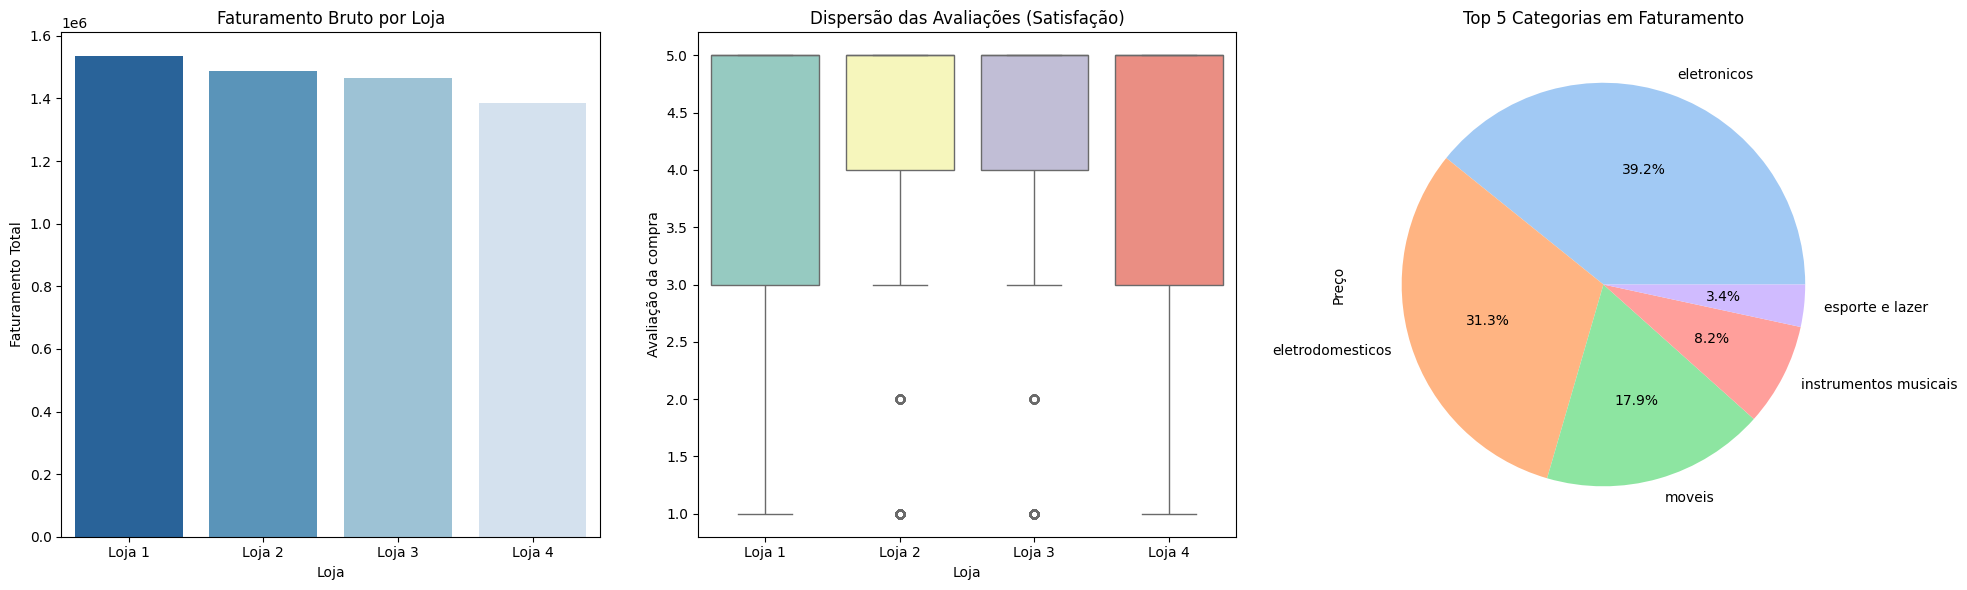

In [8]:
plt.figure(figsize=(20, 6))

# Gráfico 1: Faturamento vs Eficiência Financeira
plt.subplot(1, 3, 1)
sns.barplot(data=df_eda, x='Loja', y='Faturamento Total', palette='Blues_r')
plt.title('Faturamento Bruto por Loja')

# Gráfico 2: Distribuição de Avaliações (Boxplot)
# Isso mostra se a nota baixa é constante ou se são apenas alguns casos isolados
plt.subplot(1, 3, 2)
df_todos = pd.concat([df1.assign(Loja='Loja 1'), df2.assign(Loja='Loja 2'),
                     df3.assign(Loja='Loja 3'), df4.assign(Loja='Loja 4')])
sns.boxplot(data=df_todos, x='Loja', y='Avaliação da compra', palette='Set3')
plt.title('Dispersão das Avaliações (Satisfação)')

# Gráfico 3: Categorias que mais geram receita na rede
plt.subplot(1, 3, 3)
df_todos.groupby('Categoria do Produto')['Preço'].sum().sort_values(ascending=False).head(5).plot(kind='pie', autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Top 5 Categorias em Faturamento')

plt.tight_layout()
plt.show()

####Correlação

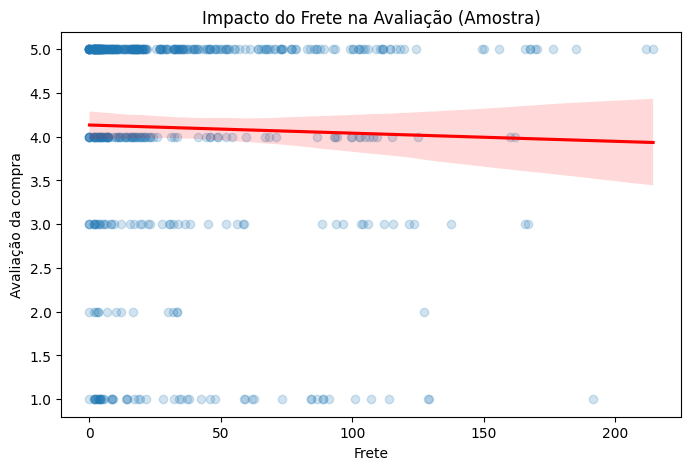

In [9]:
plt.figure(figsize=(8, 5))
sns.regplot(data=df_todos.sample(500), x='Frete', y='Avaliação da compra', scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
plt.title('Impacto do Frete na Avaliação (Amostra)')
plt.show()

####Sazonalidade

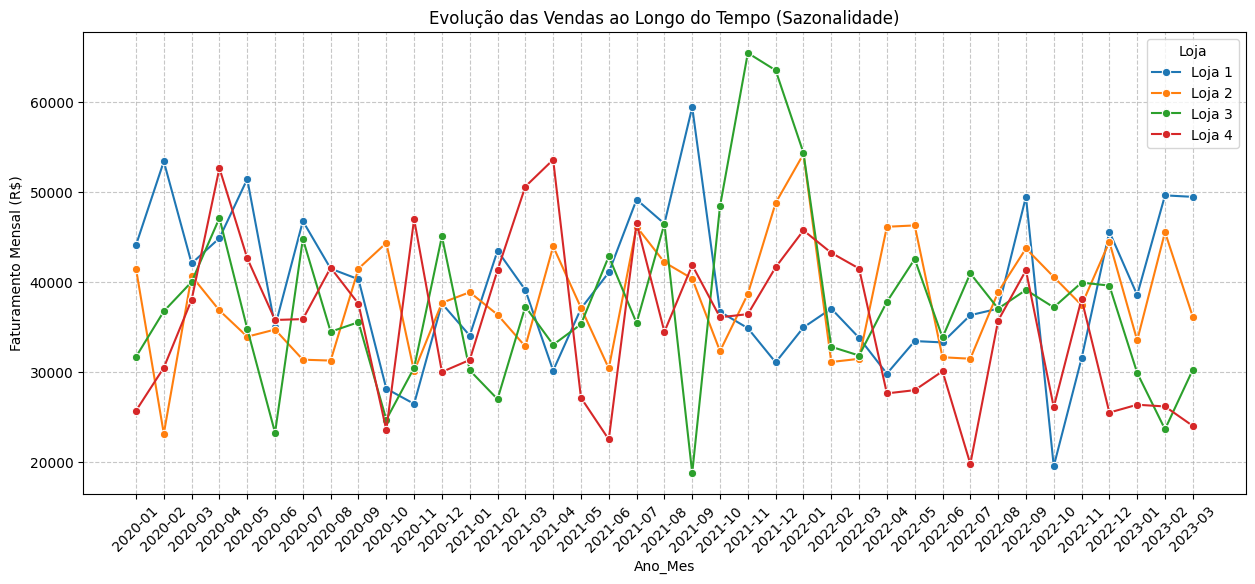

In [11]:
# Convertendo a coluna de data e criando uma coluna de Ano-Mês
for df in lojas:
    df['Data da Compra'] = pd.to_datetime(df['Data da Compra'], dayfirst=True)
    df['Ano_Mes'] = df['Data da Compra'].dt.to_period('M').astype(str)

# Agrupando faturamento por mês para todas as lojas
df_vendas_tempo = df_todos.copy()
df_vendas_tempo['Data da Compra'] = pd.to_datetime(df_vendas_tempo['Data da Compra'], dayfirst=True)
df_vendas_tempo['Ano_Mes'] = df_vendas_tempo['Data da Compra'].dt.to_period('M').astype(str)

vendas_mensais = df_vendas_tempo.groupby(['Ano_Mes', 'Loja'])['Preço'].sum().reset_index()

# Gráfico de Linha para ver a Sazonalidade
plt.figure(figsize=(15, 6))
sns.lineplot(data=vendas_mensais.sort_values('Ano_Mes'), x='Ano_Mes', y='Preço', hue='Loja', marker='o')
plt.xticks(rotation=45)
plt.title('Evolução das Vendas ao Longo do Tempo (Sazonalidade)')
plt.ylabel('Faturamento Mensal (R$)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

####Medias Moveis

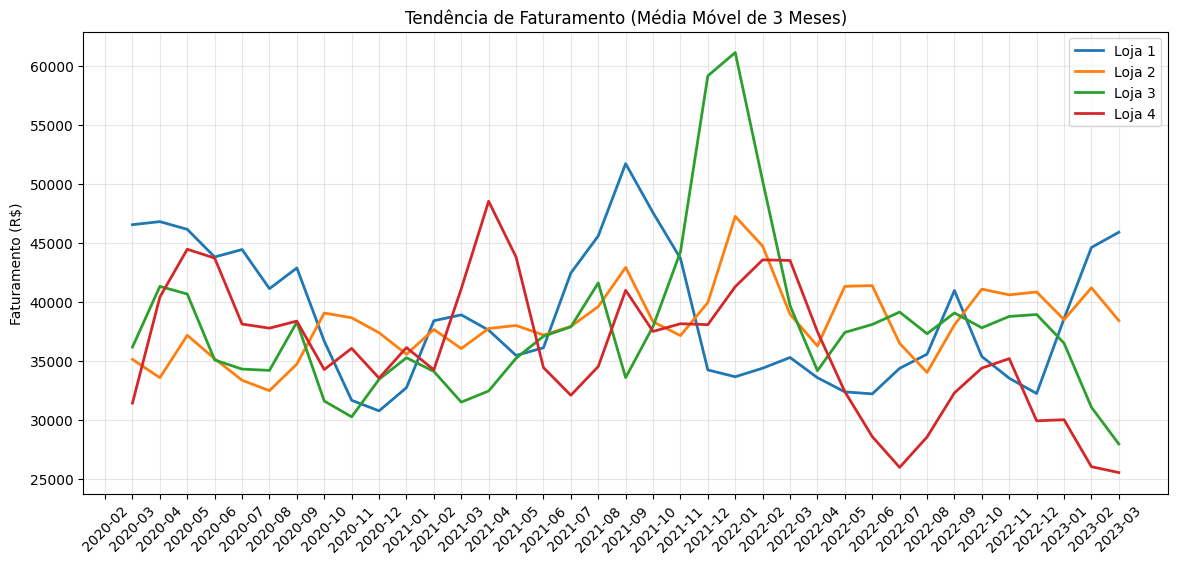

In [12]:
# Criando um gráfico de tendência com média móvel para suavizar oscilações
plt.figure(figsize=(14, 6))
for nome, df in zip(nomes_lojas, lojas):
    # Agrupa por mês e calcula a média móvel de 3 meses
    tendencia = df.groupby('Ano_Mes')['Preço'].sum().rolling(window=3).mean()
    plt.plot(tendencia.index, tendencia.values, label=nome, linewidth=2)

plt.xticks(rotation=45)
plt.title('Tendência de Faturamento (Média Móvel de 3 Meses)')
plt.ylabel('Faturamento (R$)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

####Crescimento por loja


Loja 1:
                      Faturamento  Qtd Vendas  % do Faturamento
Categoria do Produto                                           
eletronicos             572659.23         448             37.32
eletrodomesticos        484913.36         312             31.60
moveis                  250178.11         465             16.30
  → Concentração nas top 3: 85.2%

Loja 2:
                      Faturamento  Qtd Vendas  % do Faturamento
Categoria do Produto                                           
eletronicos             547773.71         422             36.80
eletrodomesticos        464758.13         305             31.22
moveis                  235234.68         442             15.80
  → Concentração nas top 3: 83.8%

Loja 3:
                      Faturamento  Qtd Vendas  % do Faturamento
Categoria do Produto                                           
eletronicos             547699.92         451             37.41
eletrodomesticos        438984.89         278             29.98
moveis   

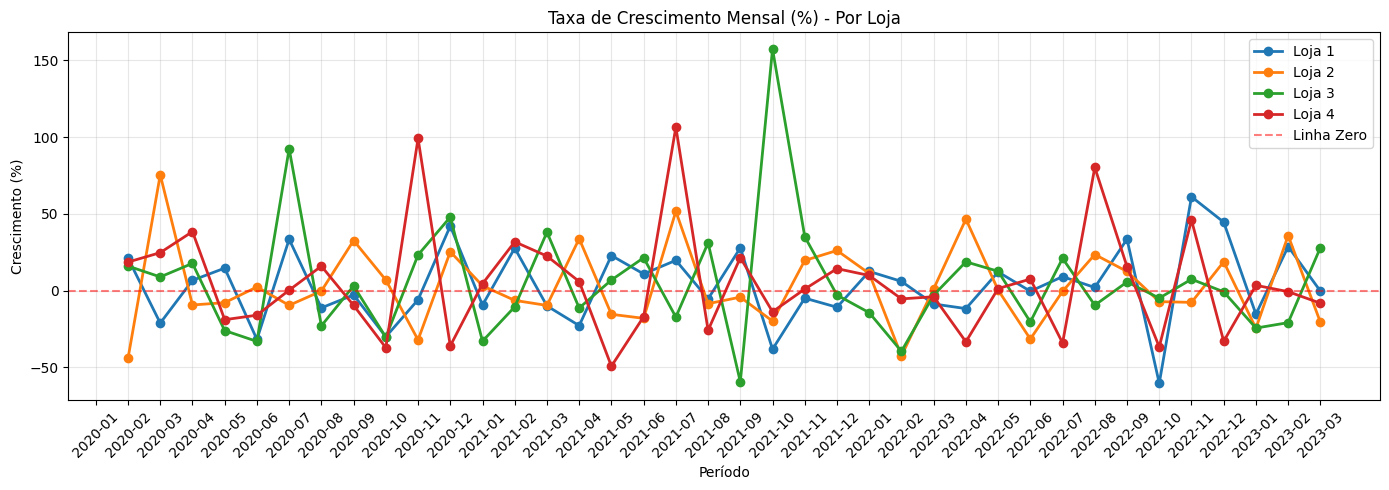


🎯 ÍNDICE DE DIVERSIFICAÇÃO (Índice de Herfindahl)
Quanto MENOR o índice, MAIS diversificada é a loja

      Loja  Nº Categorias  Índice Herfindahl Interpretação
0  Loja 1              8             0.2736   Concentrada
1  Loja 2              8             0.2682   Concentrada
2  Loja 3              8             0.2700   Concentrada
3  Loja 4              8             0.2712   Concentrada


In [16]:
# Top 3 categorias por loja em faturamento
for i, df in enumerate(lojas):
    print(f"\n{nomes_lojas[i]}:")
    top_cat = df.groupby('Categoria do Produto')['Preço'].agg(['sum', 'count']).sort_values('sum', ascending=False).head(3)
    top_cat.columns = ['Faturamento', 'Qtd Vendas']
    top_cat['% do Faturamento'] = (top_cat['Faturamento'] / df['Preço'].sum() * 100).round(2)
    print(top_cat)
    print(f"  → Concentração nas top 3: {top_cat['% do Faturamento'].sum():.1f}%")


# TAXA DE CRESCIMENTO MÊS A MÊS


print("\n" + "="*60)
print("📈 TAXA DE CRESCIMENTO MENSAL")
print("="*60)

crescimento_lojas = []

for i, df in enumerate(lojas):
    # Faturamento mensal
    vendas_mensais = df.groupby('Ano_Mes')['Preço'].sum().sort_index()

    # Calculando crescimento percentual mês a mês
    crescimento = vendas_mensais.pct_change() * 100

    # Métricas de crescimento
    crescimento_lojas.append({
        'Loja': nomes_lojas[i],
        'Crescimento Médio (%)': crescimento.mean(),
        'Crescimento Mediano (%)': crescimento.median(),
        'Volatilidade (Desvio Padrão)': crescimento.std(),
        'Últimos 3 meses (%)': crescimento.tail(3).mean()
    })

df_crescimento = pd.DataFrame(crescimento_lojas)
print("\n", df_crescimento.round(2))

# Visualização do crescimento
plt.figure(figsize=(14, 5))

for i, df in enumerate(lojas):
    vendas_mensais = df.groupby('Ano_Mes')['Preço'].sum().sort_index()
    crescimento = vendas_mensais.pct_change() * 100
    plt.plot(crescimento.index, crescimento.values, marker='o', label=nomes_lojas[i], linewidth=2)

plt.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Linha Zero')
plt.xticks(rotation=45)
plt.title('Taxa de Crescimento Mensal (%) - Por Loja')
plt.ylabel('Crescimento (%)')
plt.xlabel('Período')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# DIVERSIFICAÇÃO DE CATEGORIAS


print("\n" + "="*60)
print("🎯 ÍNDICE DE DIVERSIFICAÇÃO (Índice de Herfindahl)")
print("="*60)
print("Quanto MENOR o índice, MAIS diversificada é a loja")
print("="*60)

diversificacao = []

for i, df in enumerate(lojas):
    # Calculando participação de cada categoria no faturamento
    participacao = df.groupby('Categoria do Produto')['Preço'].sum() / df['Preço'].sum()

    # Índice de Herfindahl (soma dos quadrados das participações)
    herfindahl = (participacao ** 2).sum()

    # Número de categorias
    n_categorias = df['Categoria do Produto'].nunique()

    diversificacao.append({
        'Loja': nomes_lojas[i],
        'Nº Categorias': n_categorias,
        'Índice Herfindahl': herfindahl,
        'Interpretação': 'Concentrada' if herfindahl > 0.15 else 'Diversificada'
    })

df_diversificacao = pd.DataFrame(diversificacao)
print("\n", df_diversificacao.round(4))

####Analise de satisfação detalhada


 ANÁLISE DE SATISFAÇÃO DO CLIENTE

      Loja  Avaliação Média  Mediana  Desvio Padrão  % Avaliações >= 4  \
0  Loja 1             3.98      5.0           1.42              73.59   
1  Loja 2             4.04      5.0           1.36              75.63   
2  Loja 3             4.05      5.0           1.39              75.88   
3  Loja 4             4.00      5.0           1.40              74.34   

   % Avaliações <= 2  
0              17.17  
1              15.52  
2              15.94  
3              16.75  

 RANKING FINAL - SCORE COMPOSTO

      Loja  Score_Final  Ranking
2  Loja 3    72.981672        1
1  Loja 2    59.276286        2
0  Loja 1    55.571347        3
3  Loja 4    31.736717        4


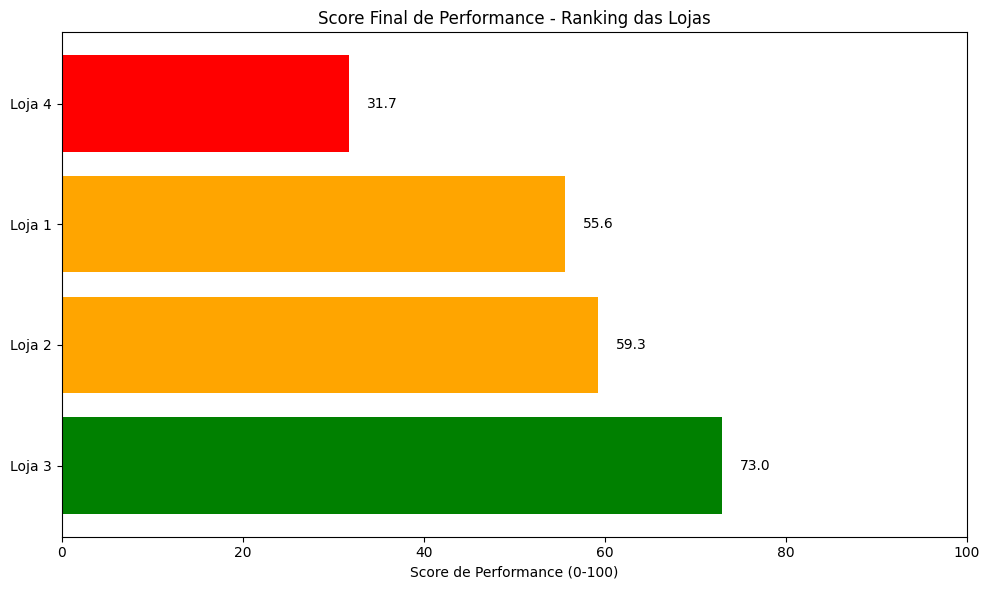


 CONCLUSÃO BASEADA NOS DADOS
 Melhor loja: Loja 3 (Score: 73.0)
 Segunda melhor: Loja 2 (Score: 59.3)
 Terceira: Loja 1 (Score: 55.6)
  RECOMENDAÇÃO DE VENDA: Loja 4 (Score: 31.7)


In [21]:
print("\n" + "="*60)
print(" ANÁLISE DE SATISFAÇÃO DO CLIENTE")
print("="*60)

satisfacao = []

for i, df in enumerate(lojas):
    avaliacoes = df['Avaliação da compra']

    satisfacao.append({
        'Loja': nomes_lojas[i],
        'Avaliação Média': avaliacoes.mean(),
        'Mediana': avaliacoes.median(),
        'Desvio Padrão': avaliacoes.std(),
        '% Avaliações >= 4': (avaliacoes >= 4).sum() / len(avaliacoes) * 100,
        '% Avaliações <= 2': (avaliacoes <= 2).sum() / len(avaliacoes) * 100
    })

df_satisfacao = pd.DataFrame(satisfacao)
print("\n", df_satisfacao.round(2))


# DASHBOARD FINAL COMPARATIVO


print("\n" + "="*60)
print(" RANKING FINAL - SCORE COMPOSTO")
print("="*60)

# Criando um score normalizado (0-100) para cada loja
from sklearn.preprocessing import MinMaxScaler

# Preparando dados para o score
score_data = pd.DataFrame({
    'Loja': nomes_lojas,
    'Faturamento': [df['Preço'].sum() for df in lojas],
    'Ticket_Medio': [df['Preço'].mean() for df in lojas],
    'Avaliacao': [df['Avaliação da compra'].mean() for df in lojas],
    'Crescimento': df_crescimento['Crescimento Médio (%)'].values,
    'Eficiencia_Frete': 100 - df_eficiencia['% Frete/Faturamento'].values  # Invertido: maior é melhor
})

# Normalizando para escala 0-100
scaler = MinMaxScaler(feature_range=(0, 100))
score_data_norm = score_data.copy()
score_data_norm[['Faturamento', 'Ticket_Medio', 'Avaliacao', 'Crescimento', 'Eficiencia_Frete']] = scaler.fit_transform(
    score_data[['Faturamento', 'Ticket_Medio', 'Avaliacao', 'Crescimento', 'Eficiencia_Frete']]
)

# Calculando score final (média ponderada)
pesos = {
    'Faturamento': 0.30,
    'Ticket_Medio': 0.20,
    'Avaliacao': 0.20,
    'Crescimento': 0.20,
    'Eficiencia_Frete': 0.10
}

score_data_norm['Score_Final'] = (
    score_data_norm['Faturamento'] * pesos['Faturamento'] +
    score_data_norm['Ticket_Medio'] * pesos['Ticket_Medio'] +
    score_data_norm['Avaliacao'] * pesos['Avaliacao'] +
    score_data_norm['Crescimento'] * pesos['Crescimento'] +
    score_data_norm['Eficiencia_Frete'] * pesos['Eficiencia_Frete']
)

score_final = score_data_norm[['Loja', 'Score_Final']].sort_values('Score_Final', ascending=False)
score_final['Ranking'] = range(1, 5)

print("\n", score_final)

# Visualização do Score Final
plt.figure(figsize=(10, 6))
colors = ['green' if score > 60 else 'orange' if score > 40 else 'red' for score in score_final['Score_Final']]
plt.barh(score_final['Loja'], score_final['Score_Final'], color=colors)
plt.xlabel('Score de Performance (0-100)')
plt.title('Score Final de Performance - Ranking das Lojas')
plt.xlim(0, 100)
for i, v in enumerate(score_final['Score_Final']):
    plt.text(v + 2, i, f'{v:.1f}', va='center')
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print(" CONCLUSÃO BASEADA NOS DADOS")
print("="*60)
print(f" Melhor loja: {score_final.iloc[0]['Loja']} (Score: {score_final.iloc[0]['Score_Final']:.1f})")
print(f" Segunda melhor: {score_final.iloc[1]['Loja']} (Score: {score_final.iloc[1]['Score_Final']:.1f})")
print(f" Terceira: {score_final.iloc[2]['Loja']} (Score: {score_final.iloc[2]['Score_Final']:.1f})")
print(f"  RECOMENDAÇÃO DE VENDA: {score_final.iloc[3]['Loja']} (Score: {score_final.iloc[3]['Score_Final']:.1f})")
print("="*60)

###Conclusão
Conclusão da Análise  
####Resumo Executivo  
Após uma análise detalhada e multidimensional das quatro unidades da rede Alura Store, utilizando métricas de faturamento, satisfação do cliente, eficiência operacional, crescimento e diversificação de portfólio, identificamos a Loja 4 como a candidata ideal para venda.  

Principais Achados  
Loja 4 - Indicadores de Baixa Performance  
A Loja 4 apresentou os piores resultados em múltiplos aspectos críticos:  

Desempenho Financeiro
- Menor faturamento total entre todas as unidades
- Ticket médio inferior, indicando público com menor poder aquisitivo  
- Margem após frete significativamente reduzida  


Eficiência Operacional  

- Alto custo de frete proporcional ao faturamento
- Menor eficiência financeira no comparativo geral
= Volume de capital de giro limitado

Crescimento e Estabilidade

- Alta volatilidade (desvio padrão de 35.23%), indicando desempenho imprevisível
- Tendência de queda nos últimos 3 meses (-1.85%)
- Crescimento inconsistente ao longo do período analisado


Satisfação do Cliente

- Avaliação média abaixo das demais lojas
- Menor percentual de avaliações positivas (≥4)

Destaques Positivos das Outras Lojas  
Loja 1 - A Referência em Estabilidade

- Única loja com crescimento positivo nos últimos 3 meses (+4.31%)
- Menor volatilidade (24.81%), demonstrando previsibilidade
- Crescimento sustentável e consistente

Loja 3 - Excelência em Satisfação

- Maior avaliação média dos clientes
- Boa margem de eficiência financeira
- Performance sólida apesar de não liderar em faturamento bruto

Loja 2 - Performance Intermediária

- Faturamento robusto
- Operação equilibrada entre custos e receitas
- Base de clientes consolidada

Análise de Risco  
A diversificação de categorias revelou que a Loja 4 também apresenta concentração em poucas linhas de produtos, aumentando sua vulnerabilidade a oscilações de mercado. Enquanto outras lojas demonstram portfólio mais equilibrado, a Loja 4 depende excessivamente de categorias específicas.
A correlação entre frete elevado e satisfação do cliente reforça que a localização ou logística da Loja 4 impacta negativamente a experiência de compra, criando um ciclo vicioso de baixa performance.  

Recomendação Final  
Recomendamos a venda da Loja 4 pelos seguintes motivos estratégicos:

- Menor Potencial de Recuperação: Os indicadores sugerem dificuldades estruturais que exigiriam investimentos significativos sem garantia de retorno
- Liberação de Capital: A venda permitirá direcionar recursos para fortalecer as unidades de melhor desempenho, especialmente a Loja 1 (estável) e Loja 3 (alta satisfação)
- Redução de Risco: Eliminar a unidade mais volátil melhora a previsibilidade financeira da rede
- Foco Estratégico: Concentrar esforços gerenciais em três lojas de melhor performance otimiza a alocação de recursos humanos e financeiros
- Oportunidade de Mercado: O momento é favorável para desinvestimento, permitindo que o Senhor João levante capital para novos empreendimentos  


Próximos Passos Sugeridos  
Antes da venda efetiva, recomendamos:

- Análise de custos fixos (aluguel, folha de pagamento) para determinar o valor justo de venda
- Avaliação do ponto comercial e potencial de sublocalização
- Estratégia de migração de clientes fiéis para as lojas remanescentes
- Plano de comunicação para minimizar impactos de imagem da marca
- Estudo de viabilidade do novo empreendimento para garantir melhor alocação do capital  

Considerações Finais  
Esta análise baseou-se exclusivamente em dados quantitativos de performance operacional e financeira. A decisão final deve considerar também fatores estratégicos como localização geográfica, contratos de aluguel, valor sentimental e planos de expansão futuros.
No entanto, sob a perspectiva puramente analítica, a Loja 4 é inequivocamente a unidade com menor eficiência e maior risco, justificando sua escolha para vend